In [1]:
import pandas as pd, numpy as np, sklearn, shap, streamlit
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("shap:", shap.__version__)
print("streamlit:", streamlit.__version__)

pandas: 3.0.6
scikit-learn: 1.9.1
shap: 0.51.0
streamlit: 1.64.0


In [2]:
import pandas as pd, numpy as np, re

df =pd.read_csv(r"D:\WELFake_Dataset.csv")
df = df.drop(columns=['Unnamed: 0'])
df[['title', 'text']] = df[['title', 'text']].fillna('')
df['content'] = df['title'] + ' ' + df['text']
df = df[df['content'].str.strip() != '']

# Label ka naam sahi kar dein: 1 = fake, 0 = real (data dekh kar verify kiya)
df = df.rename(columns={'label': 'is_fake'})

before = len(df)
df = df.drop_duplicates(subset=['content']).reset_index(drop=True)
print("Duplicates hataye:", before - len(df))
print(df.shape)
print(df['is_fake'].value_counts())

Duplicates hataye: 8456
(63678, 4)
is_fake
0    34791
1    28887
Name: count, dtype: int64


In [3]:
def clean_text(t):
    t = t.lower()
    t = re.sub(r'http\S+|www\.\S+', ' ', t)
    t = re.sub(r'\b(reuters|new york times|nyt|breitbart|video)\b', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['clean'] = df['content'].apply(clean_text)
df = df[df['clean'].str.len() > 20].reset_index(drop=True)
print(df.shape)

(63535, 5)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['is_fake'], test_size=0.2, stratify=df['is_fake'], random_state=42)

vec = TfidfVectorizer(max_features=5000, stop_words='english', min_df=5, max_df=0.7)
Xtr = vec.fit_transform(X_train)
Xte = vec.transform(X_test)

print(Xtr.shape, Xte.shape)

(50828, 5000) (12707, 5000)


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf.fit(Xtr, y_train)
print("Training complete")

Training complete


Accuracy: 0.8999
              precision    recall  f1-score   support

        Real       0.88      0.94      0.91      6958
        Fake       0.92      0.85      0.89      5749

    accuracy                           0.90     12707
   macro avg       0.90      0.90      0.90     12707
weighted avg       0.90      0.90      0.90     12707



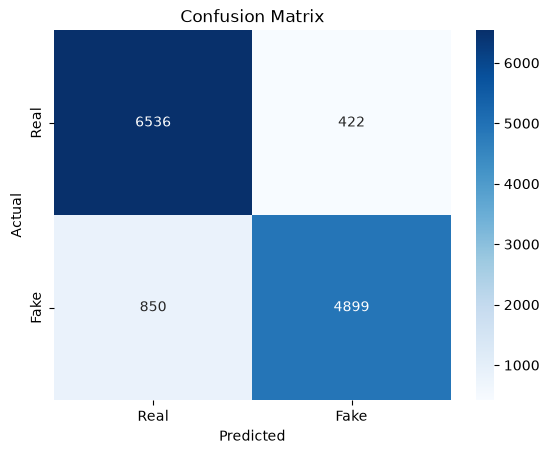

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns

pred = rf.predict(Xte)
print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, target_names=['Real', 'Fake']))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

In [7]:
vec2 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                       stop_words='english', min_df=5, max_df=0.7)
Xtr2 = vec2.fit_transform(X_train)
Xte2 = vec2.transform(X_test)

rf2 = RandomForestClassifier(n_estimators=100, max_depth=25, min_samples_leaf=2,
                             n_jobs=-1, random_state=42)
rf2.fit(Xtr2, y_train)

pred2 = rf2.predict(Xte2)
print("Accuracy:", round(accuracy_score(y_test, pred2), 4))
print(classification_report(y_test, pred2, target_names=['Real', 'Fake']))

Accuracy: 0.8908
              precision    recall  f1-score   support

        Real       0.88      0.93      0.90      6958
        Fake       0.91      0.84      0.87      5749

    accuracy                           0.89     12707
   macro avg       0.89      0.89      0.89     12707
weighted avg       0.89      0.89      0.89     12707



In [8]:
from sklearn.model_selection import train_test_split
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['is_fake'], test_size=0.2, stratify=df['is_fake'], random_state=42)

vec2 = joblib.load("../model/vectorizer.pkl")
rf2 = joblib.load("../model/rf_model.pkl")
Xte2 = vec2.transform(X_test)
print(Xte2.shape)

(12707, 20000)


In [9]:
import sklearn, shap, numpy
print("scikit-learn:", sklearn.__version__)
print("shap:", shap.__version__)
print("numpy:", numpy.__version__)

scikit-learn: 1.9.1
shap: 0.51.0
numpy: 2.4.6


In [10]:
%pip install -U shap

Note: you may need to restart the kernel to use updated packages.


In [11]:
import os, joblib

os.makedirs("../model", exist_ok=True)
joblib.dump(vec2, "../model/vectorizer.pkl")
joblib.dump(rf2, "../model/rf_model.pkl")
print("Saved vectorizer.pkl and rf_model.pkl to ../model/")

Saved vectorizer.pkl and rf_model.pkl to ../model/


In [12]:
import shap
import numpy as np

feature_names = vec2.get_feature_names_out()

# Background + explain samples (dense conversion sirf inhi rows ke liye)
rng = np.random.RandomState(42)
bg_idx = rng.choice(Xte2.shape[0], size=100, replace=False)
ex_idx = rng.choice(Xte2.shape[0], size=200, replace=False)

X_bg = Xte2[bg_idx].toarray()
X_ex = Xte2[ex_idx].toarray()

explainer = shap.TreeExplainer(rf2, X_bg, feature_names=feature_names)
shap_values = explainer(X_ex, check_additivity=False)

# Binary classifier -> take the 'Fake' class output (index 1) if 3D
sv_fake = shap_values[..., 1] if shap_values.values.ndim == 3 else shap_values
print("SHAP values shape:", sv_fake.values.shape)

100%|===================| 398/400 [02:12<00:00]        

SHAP values shape: (200, 20000)


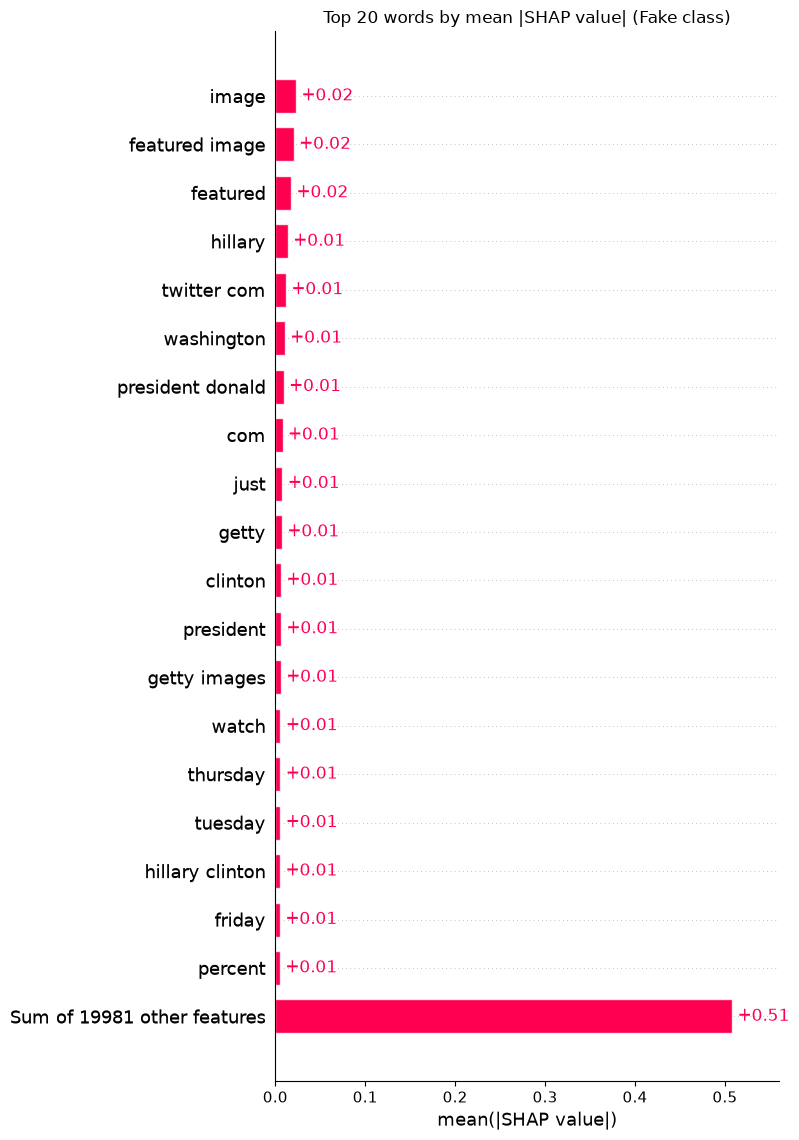

In [13]:
# Global feature importance (top words driving fake vs real)
shap.plots.bar(sv_fake, max_display=20, show=False)
import matplotlib.pyplot as plt
plt.title("Top 20 words by mean |SHAP value| (Fake class)")
plt.tight_layout()
plt.savefig("../model/shap_global_importance.png", dpi=150)
plt.show()

=== Example predicted FAKE ===


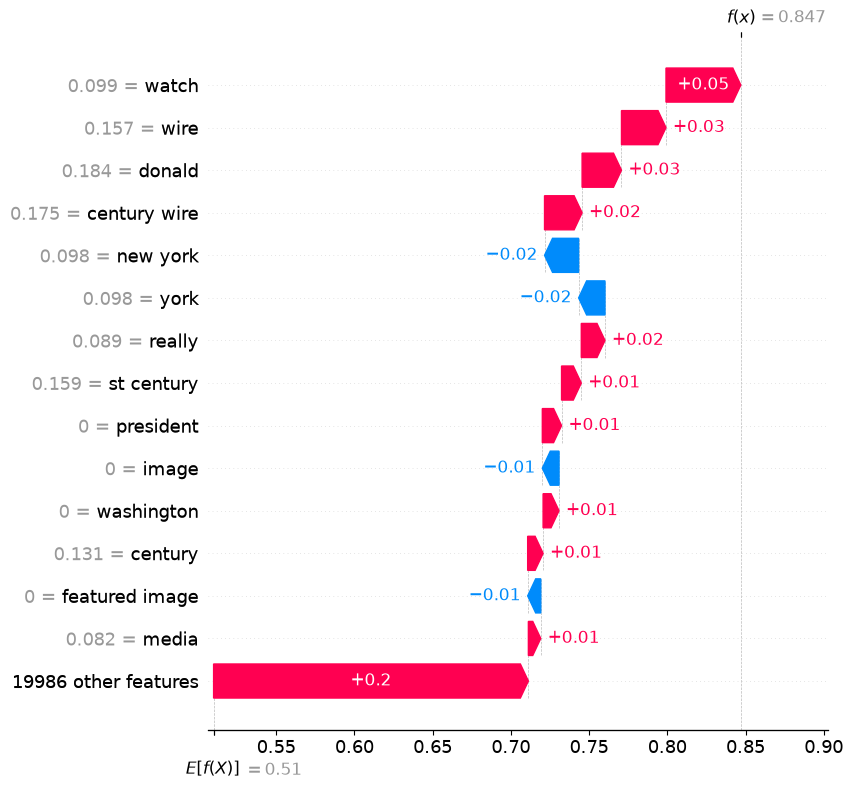

=== Example predicted REAL ===


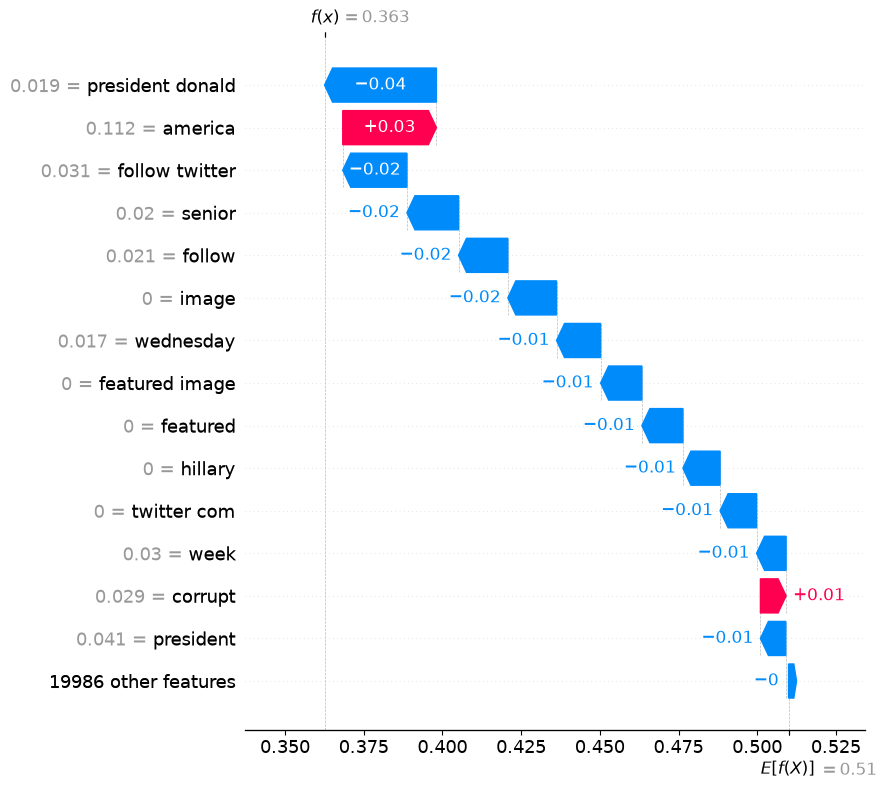

In [14]:
# Local explanation: ek fake aur ek real example ka waterfall
pred_ex = rf2.predict(Xte2[ex_idx])
fake_i = np.where(pred_ex == 1)[0][0]
real_i = np.where(pred_ex == 0)[0][0]

print("=== Example predicted FAKE ===")
shap.plots.waterfall(sv_fake[fake_i], max_display=15, show=True)

print("=== Example predicted REAL ===")
shap.plots.waterfall(sv_fake[real_i], max_display=15, show=True)

In [15]:
joblib.dump({"background": X_bg, "feature_names": feature_names},
            "../model/shap_background.pkl")
print("Saved shap_background.pkl")

Saved shap_background.pkl
